In [1]:
import sys
import os

project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))

if project_root not in sys.path:
    sys.path.insert(0, project_root)

from scripts.utils import *
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import confusion_matrix, classification_report

from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Rescaling, Dropout ,Input
from keras.callbacks import TensorBoard, ModelCheckpoint, EarlyStopping
from keras.optimizers import SGD, Adam
from keras import layers
from keras.applications import ResNet50

import keras_cv

mixed_precision.set_global_policy("mixed_float16")

C:\Users\faarc\AppData\Roaming\Python\Python311\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
def compute_classification_metrics(y_true, y_pred, class_names):
    '''Computes confusion matrix based on prediction and true labels.
    
    Args:
        - y_true (np.array): true labels of a dataset.
        - y_pred (np.array): predicted labels.
        - class_names (list): index-ordered class names.
        
    Returns:
        - cm: confusion matrix.
        - Also prints a classification report.
    
    '''
    cm = confusion_matrix(y_true, y_pred)
    str_summary = classification_report(y_true, y_pred, target_names=class_names)
    print(str_summary)
    
    # todo: manually compute other metrics
    return cm

In [3]:
# directory where images are located
data_dir = "../data/original"
image_size = (32, 32)
batch_size = 16

file_paths = []
labels = []

# the name of each folder corresponds to the label of the images within
class_names = os.listdir(data_dir)
class_to_index = {name: i for i, name in enumerate(class_names)}

# for each folder, we'll save the path of each file with its correspondent label
for class_name in class_names:
    class_dir = f"{data_dir}/{class_name}"
    images = sorted(os.listdir(class_dir))
    for img_path in images:
        file_paths.append(class_dir + "/" + str(img_path))
        labels.append(class_to_index[class_name])

# now we have all the paths and labels together
file_paths = np.array(file_paths)

# bad_files = []

# for path in file_paths:
#     try:
#         if not check_jpeg(path):
#             bad_files.append(path)
#     except:
#         bad_files.append(path)

# print("invalid files:" +  str(len(bad_files)))

# todo: include if

# fix bad_files (already done)
# for path in bad_files:
#     img = Image.open(path)
#     new_path = path.rsplit(".", 1)[0] + ".jpg"
#     img.convert("RGB").save(new_path, "JPEG")

In [4]:
labels = np.array(labels)
dimension = 3

X_train, X_test, y_train, y_test = train_test_split(
    file_paths,
    labels,
    test_size=0.2,
    stratify=labels,
    random_state=42
)

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train),
    y=y_train
)

cv_train_set = tf.data.Dataset.from_tensor_slices((X_train, y_train))
cv_train_set = cv_train_set.map(preprocess_image, num_parallel_calls=tf.data.AUTOTUNE)
cv_train_set = cv_train_set.shuffle(int(len(file_paths))).batch(batch_size).prefetch(tf.data.AUTOTUNE)

cv_test_set = tf.data.Dataset.from_tensor_slices((X_test, y_test))
cv_test_set = cv_test_set.map(preprocess_image, num_parallel_calls=tf.data.AUTOTUNE)
cv_test_set = cv_test_set.batch(batch_size).prefetch(tf.data.AUTOTUNE)

X_test_array, y_test_array = pass_batchs_to_arrays(cv_test_set, pass_dummy=True)

In [5]:
def pass_batchs_to_arrays(dset, pass_dummy = False):
    '''Takes a TensorFlow dataset and converts it to its respective features and labels arrays.
    
    Args:
        - dset: tensorflow dataset.
        - pass_dummy (bool): sets if labels should be returned in a one-hot format.
        
    Returns:
        - X (np.array): features dataset.
        - y (np.array): labels dataset.
    
    '''

    X_list = []
    y_list = []

    for x_batch, y_batch in dset:
        X_list.append(x_batch.numpy())
        y_list.append(y_batch.numpy())

    X = np.concatenate(X_list, axis=0)
    y = np.concatenate(y_list, axis=0)
    
    if pass_dummy:
        y = np.argmax(y, axis = 1)
    
    return X, y

In [6]:
def plot_conf_matrix(cm):
    ''' Plots a confusion matrix coming from the compute_classification_metrics function
    
    Args:
        - cm: confusion matrix.
    Returns:
        - Plot of the confusion matrix.
        
    '''
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", 
                xticklabels=class_names, yticklabels=class_names)
    plt.xlabel("pred")
    plt.ylabel("true")
    plt.show()

In [7]:
class_weights = dict(enumerate(class_weights))

## Baseline

In [8]:
def build_baseline_model(n_filters = 64, n_neurons = 64, learning_rate = 1e-2, momentum = 0.0, 
                      kernel_size = 3, pool_size = 2, sparse = False, **kwargs):
    '''Builds the first CNN architecture. This model is intended to be very simple, to start understanding how well it performs over the dataset
        and to start developing more complex models. It uses basic concepts of CNNs: a convolution layer followed by a pooling layer, then a dense layer with a final
        softmax given output.
        
    Args:
        - n_filters (int): number of filters to be used on convolution layers (Conv2D). Default set to 64.
        - n_neurons (int): number of neurons to be used on dense layers (Dense). Default set to 64.
        - learning_rate (float): indicates a which rate the gradient moves. Default set to 1e-2.
        - momentum (float): proportion regarding how much of past gradients affect the current gradient step. Default set to 0.0.
        - kernel_size (int): indicates the size of the squared sliding window over the feature map. Default set to 3.
        - pool_size (int): indicated the size of the downsample pooling window. Default set to 2.
        - sparse (bool): sets if labels should be considered as one-hot (False) or integers (True). Default set to True.
        - other parameters such as activation function (ReLU), padding (same) and activation (softmax) were kept as default throught all architectures.
    Returns:
        - model: fully compiled model with all respective features.
    
    '''
    
    normalization_layer = Rescaling(1./255)
    
    model = Sequential([
    Input(shape = (image_size[0], image_size[1], dimension)),
    normalization_layer,
    Conv2D(n_filters, kernel_size, activation = "relu", padding = "same"),
    MaxPooling2D(pool_size),
    Flatten(),
    Dense(n_neurons, activation="relu"),
    Dense(10, activation = "softmax")
                    ])
    
    # for the first model only SGD optimizer is used.
    optimizer = SGD(learning_rate=learning_rate, momentum=momentum)
    
    loss = "categorical_crossentropy"
    if sparse:
        loss = "sparse_categorical_crossentropy"
    model.compile(loss = loss,
        optimizer = optimizer,
        metrics = ["accuracy"])
    
    return model

In [6]:
%%time

param_grid = {"learning_rate": [1e-2],
              "momentum": [0.0],
              "kernel_size": [2],
              "n_filters": [32],
              "n_neurons": [32]}

# X_train, X_test, y_train, y_test
best_params, best_accuracy, mean_scores  = CNN_GridSearchCV(X_train, y_train, param_grid, build_baseline_model, 42, 5, n_jobs = -1)

CPU times: total: 1.52 s
Wall time: 6min 12s


In [7]:
best_params

{'learning_rate': 0.01,
 'momentum': 0.0,
 'kernel_size': 2,
 'n_filters': 32,
 'n_neurons': 32}

In [8]:
mean_scores

[(np.float64(1.426674747467041), np.float64(0.5119892299175263))]

In [ ]:
which_arch = "baseline"

run_id, run_logdir = get_run_logdir(which_arch, "1")

# different callbacks to: save the best model over validation set, save logs of loss and accuracy for later visualization and early stopping.
tensorboard_cb = TensorBoard(run_logdir)
early_stopping = EarlyStopping(patience = 5, monitor = "loss")

# compile the model
model = build_baseline_model(**best_params, sparse= False)

# train
# we use a higher number of epochs since early stopping should stop since it reaches a no-improvement point.
model.fit(cv_train_set, epochs=50, class_weight=class_weights, callbacks= [tensorboard_cb, early_stopping])

table_from_history(model.history.history, run_id).to_csv("curves_data/"+which_arch+"/"+run_id+".csv")

# with the best parameters achieved, we train the first model and evaluate for the test error
save_params(run_logdir, "best_params_baseline_model.pkl",best_params)

Epoch 1/50
668/668 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - accuracy: 0.1433 - loss: 2.2680
Epoch 2/50
668/668 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - accuracy: 0.2606 - loss: 1.9685
Epoch 3/50
668/668 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - accuracy: 0.3496 - loss: 1.8029
Epoch 4/50
668/668 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - accuracy: 0.4075 - loss: 1.6686
Epoch 5/50
668/668 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - accuracy: 0.4610 - loss: 1.5582
Epoch 6/50
668/668 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - accuracy: 0.4931 - loss: 1.4569
Epoch 7/50
668/668 ━━━━━━━━━━━━━━━━━━━━ 11s 10ms/step - accuracy: 0.5276 - loss: 1.3575
Epoch 8/50
668/668 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - accuracy: 0.5423 - loss: 1.3190
Epoch 9/50
668/668 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - accuracy: 0.5708 - loss: 1.2262
Epoch 10/50
668/668 ━━━━━━━━━━━━━━━━━━━━ 11s 10ms/step - accuracy: 0.5899 - loss: 1.1888
Epoch 11/50
668/668 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - accuracy: 0.6132 - loss: 1.1152
Epoch 12/50
668/668 ━━━━━━━━━━━━━━

In [12]:
model.evaluate(cv_test_set)

167/167 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.5937 - loss: 2.2213


[2.2982258796691895, 0.5689138770103455]

In [13]:
y_pred = np.argmax(model.predict(cv_test_set), axis = 1)

167/167 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


In [20]:
cm = compute_classification_metrics(y_test_array, y_pred, class_names)

              precision    recall  f1-score   support

     battery       0.63      0.67      0.65       163
  biological       0.58      0.60      0.59       162
   cardboard       0.63      0.59      0.61       306
     clothes       0.74      0.75      0.74       397
       glass       0.54      0.58      0.56       400
       metal       0.36      0.29      0.32       198
       paper       0.48      0.42      0.45       276
     plastic       0.49      0.61      0.54       342
       shoes       0.62      0.54      0.57       327
       trash       0.49      0.42      0.45        99

    accuracy                           0.57      2670
   macro avg       0.55      0.55      0.55      2670
weighted avg       0.57      0.57      0.57      2670



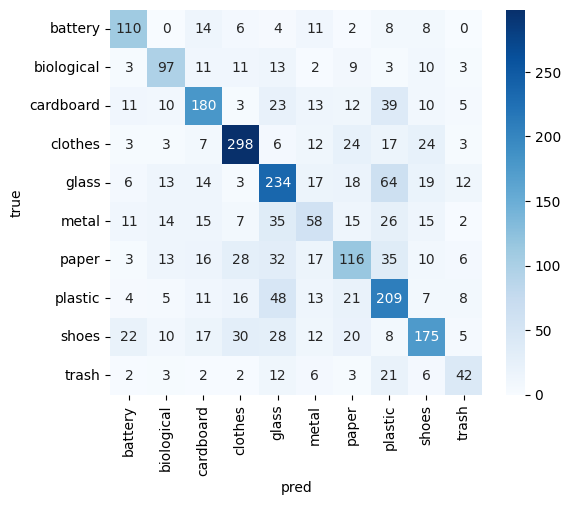

In [23]:
plot_conf_matrix(cm)

## Custom model

In [9]:
def build_custom_model(n_filters = 128, n_neurons = 64, learning_rate = 1e-2, dropout_rate = 0.5, 
                      kernel_size = 3, pool_size = 2, sparse = False, momentum = 0.9 ,**kwargs):
    '''
    
    '''
    
    normalization_layer = Rescaling(1./255)
    
    model = Sequential([
    Input(shape = (image_size[0], image_size[1], dimension)),
    normalization_layer,
    Conv2D(n_filters, kernel_size, activation = "relu", padding = "same"),
    MaxPooling2D(pool_size),
    Conv2D(int(n_filters*2), kernel_size, activation = "relu", padding = "same"),
    MaxPooling2D(pool_size),
    Flatten(),
    Dense(n_neurons, activation="relu"),
    Dropout(dropout_rate),
    Dense(int(n_neurons/2), activation="relu"),
    Dropout(dropout_rate),
    Dense(10, activation = "softmax")
                    ])
    
    # for the first model only SGD optimizer is used.
    optimizer = SGD(learning_rate=learning_rate, momentum=momentum)
    
    loss = "categorical_crossentropy"
    if sparse:
        loss = "sparse_categorical_crossentropy"
    model.compile(loss = loss,
        optimizer = optimizer,
        metrics = ["accuracy"])
    
    return model

In [30]:
param_grid = {"learning_rate": [1e-2, 1e-3],
              "momentum": [0.0, 0.9],
              "n_filters": [16, 32],
              "n_neurons": [32, 64]}

# X_train, X_test, y_train, y_test
best_params, best_accuracy, mean_scores  = CNN_GridSearchCV(X_train, y_train, param_grid, build_custom_model, 42, 5, n_jobs = -1)

In [31]:
best_accuracy

np.float64(0.5004683017730713)

In [ ]:
best_params

{'learning_rate': 0.01, 'momentum': 0.9, 'n_filters': 32, 'n_neurons': 64}

In [32]:
mean_scores

[(np.float64(2.025039267539978), np.float64(0.2869467794895172)),
 (np.float64(1.8075085878372192), np.float64(0.37600637078285215)),
 (np.float64(1.990841031074524), np.float64(0.3124181032180786)),
 (np.float64(1.7467060327529906), np.float64(0.4047529995441437)),
 (np.float64(1.7730571508407593), np.float64(0.33742126226425173)),
 (np.float64(1.5225725889205932), np.float64(0.47002930045127866)),
 (np.float64(1.716801905632019), np.float64(0.37534734010696413)),
 (np.float64(1.4602400064468384), np.float64(0.5004683017730713)),
 (np.float64(2.273436260223389), np.float64(0.15293270945549012)),
 (np.float64(2.259188652038574), np.float64(0.17512612640857697)),
 (np.float64(2.2630030155181884), np.float64(0.17858352959156037)),
 (np.float64(2.240165185928345), np.float64(0.18121323883533477)),
 (np.float64(2.0536321640014648), np.float64(0.2746737986803055)),
 (np.float64(1.7808573722839356), np.float64(0.36767123341560365)),
 (np.float64(1.9676074981689453), np.float64(0.326467299461

In [10]:
which_arch = "custom"
run_id, run_logdir = get_run_logdir(which_arch, "2")
# save_params(run_logdir, "best_params_custom_model.pkl", best_params)
best_params = {'learning_rate': 0.01, 'momentum': 0.9, 'n_filters': 32, 'n_neurons': 64}

In [11]:
path_best_first_arch = "/custom/2_run_2026_02_28-00_03_05"
# params_first_arch = load_params(logs_path+path_best_first_arch+"/best_params_first_model.pkl")
model_first_arch = tf.keras.models.load_model(logs_path+path_best_first_arch+"/custom_model.keras")

In [15]:
model_checkpoint = ModelCheckpoint(run_logdir +"\\custom_model.keras", save_best_only=True)
tensorboard_cb = TensorBoard(run_logdir)
early_stopping = EarlyStopping(patience = 5, monitor = "loss")

model = build_custom_model(**best_params, sparse= False)    
# here we can save the best model
model.fit(cv_train_set, epochs=50, callbacks= [tensorboard_cb,model_checkpoint, early_stopping])

table_from_history(model.history.history, run_id).to_csv("curves_data/"+which_arch+"/"+run_id+".csv")

Epoch 1/50
116/668 ━━━━━━━━━━━━━━━━━━━━ 1:18 141ms/step - accuracy: 0.1295 - loss: 2.2990

KeyboardInterrupt: 

In [13]:

print("GPUs available:", tf.config.list_physical_devices('GPU'))

GPUs available: []


In [14]:
tf.debugging.set_log_device_placement(True)

In [16]:
tf.test.gpu_device_name()

''